In [16]:
# Setup: Import enhanced functions and set Reddit API credentials
import os
import pandas as pd
import numpy as np
import yfinance as yf
import plotly as plt    

monthly = pd.read_csv('out/reddit/reddit_monthly_sentiment.csv')


410 min


In [17]:
print(f"RESULTS SUMMARY:")
print(f"Monthly observations: {len(monthly):,}")
print(f"Tickers covered: {monthly['ticker'].nunique()}")
print(f"Date range: {monthly['month'].min()} to {monthly['month'].max()}")
print(f"Sentiment coverage: {monthly['sent_mean'].notna().mean():.1%}")

# Coverage analysis by ticker
coverage_stats = (monthly.groupby('ticker')
                 .agg(
                     months_covered=('month', 'nunique'),
                     total_posts=('n_posts', 'sum'),
                     avg_sentiment=('sent_mean', 'mean')
                 )
                 .reset_index())

# Calculate coverage percentage (assuming data spans from 2015 to present)
total_months = monthly['month'].nunique()
coverage_stats['coverage_pct'] = 100.0 * coverage_stats['months_covered'] / total_months
coverage_stats = coverage_stats.sort_values('coverage_pct', ascending=False)

print(f"\nCOVERAGE BY TICKER:")
for _, row in coverage_stats.iterrows():
    print(f"   {row['ticker']}: {row['coverage_pct']:.1f}% ({row['months_covered']}/{total_months} months, {row['total_posts']:.0f} posts)")



RESULTS SUMMARY:
Monthly observations: 763
Tickers covered: 19
Date range: 2015-01 to 2025-09
Sentiment coverage: 97.9%

COVERAGE BY TICKER:
   APP: 92.1% (116/126 months, 982 posts)
   GOOG: 53.2% (67/126 months, 570 posts)
   IONQ: 42.1% (53/126 months, 885 posts)
   RDDT: 41.3% (52/126 months, 672 posts)
   AI: 40.5% (51/126 months, 681 posts)
   QBTS: 39.7% (50/126 months, 933 posts)
   MSFT: 37.3% (47/126 months, 1043 posts)
   VERU: 37.3% (47/126 months, 1278 posts)
   ASML: 36.5% (46/126 months, 408 posts)
   SMR: 31.7% (40/126 months, 1444 posts)
   MU: 31.0% (39/126 months, 1277 posts)
   NVDA: 30.2% (38/126 months, 1020 posts)
   QQQ: 22.2% (28/126 months, 194 posts)
   PLTR: 16.7% (21/126 months, 819 posts)
   AMD: 15.9% (20/126 months, 856 posts)
   RGTI: 15.1% (19/126 months, 756 posts)
   MRVL: 11.1% (14/126 months, 1186 posts)
   ARBE: 7.9% (10/126 months, 475 posts)
   AEM: 4.0% (5/126 months, 600 posts)


In [18]:
monthly.attention_z.fillna(0, inplace=True)
monthly.dropna(subset=['sent_mean', 'sent_ew_weighted', 'sent_median'], inplace=True)

# Choose which sentiment column to test
SENT_COL = "sent_median"   # or "sent_mean", "sent_median"

# Load your monthly sentiment
sent = monthly.copy()
# month column is 'YYYY-MM' -> convert to Period(M)
sent['month'] = pd.PeriodIndex(sent['month'].astype(str), freq='M')
sent['ticker'] = sent['ticker'].str.upper()

# Figure out the time range + ticker list we actually need
tickers = sorted(sent['ticker'].unique().tolist())
start = sent['month'].min().to_timestamp(how='start')
end   = (sent['month'].max().to_timestamp(how='end') + pd.Timedelta(days=1))  # inclusive range for yfinance

# Pull monthly prices from Yahoo (auto-adjusted closes)
px = yf.download(tickers=tickers, start=start, end=end, interval='1mo',
                 auto_adjust=False, progress=False)['Adj Close']

# Index to monthly Periods, compute log returns
px.index = pd.PeriodIndex(px.index, freq='M')
ret = np.log(px / px.shift(1))

# Melt to (ticker, month, ret_1m_log)
ret_long = (ret.stack()
               .rename("ret_1m_log")
               .reset_index())
ret_long.columns = ['month', 'ticker', 'ret_1m_log']
ret_long['ticker'] = ret_long['ticker'].astype(str).str.upper()

# Merge with sentiment for the *same* month
df = sent.merge(ret_long, on=['ticker','month'], how='inner')

df


/var/folders/lj/jghsddqd5mxbhxdb6mwg7qcw0000gn/T/ipykernel_4411/1678952905.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  monthly.attention_z.fillna(0, inplace=True)
/Users/nataliamarko/miniconda3/envs/demand_forecast_env/lib/python3.12/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


,ticker,month,n_posts,mentions_textual,mentions_per_day,attention_z,sent_mean,sent_median,sent_ew_weighted,ret_1m_log
0,AEM,2025-05,120,117,3.870968,0.000000,-0.083557,-0.065530,-0.140127,0.003481
1,AEM,2025-06,120,118,4.000000,0.000000,-0.049471,-0.025639,-0.060735,0.011326
2,AEM,2025-07,120,119,3.870968,1.224745,-0.032812,-0.006262,-0.063065,0.044646
3,AEM,2025-08,120,118,3.870968,0.000000,0.010827,0.042867,-0.028677,0.147813
4,AEM,2025-09,120,115,4.000000,-1.769303,-0.057899,-0.062003,-0.084521,0.071202
...,...,...,...,...,...,...,...,...,...,...
616,VERU,2023-06,9,9,0.300000,-0.963585,0.080488,0.075281,0.132872,0.184004
617,VERU,2023-08,2,2,0.064516,-1.537325,0.573648,0.573648,0.557903,-0.191891
618,VERU,2024-05,1,1,0.032258,-1.593487,0.965853,0.965853,0.965853,-0.290154
619,VERU,2025-08,120,118,3.870968,3.246593,-0.073567,0.044343,-0.247237,-0.389961


In [21]:
df.ticker.unique()

array(['AEM', 'AI', 'AMD', 'APP', 'ARBE', 'ASML', 'GOOG', 'IONQ', 'MRVL',
       'MSFT', 'MU', 'NVDA', 'PLTR', 'QBTS', 'QQQ', 'RDDT', 'RGTI', 'SMR',
       'VERU'], dtype=object)

In [10]:
from scipy.stats import pearsonr
def _pearson(x, y):
    if len(x) < 3:
        return np.nan, np.nan
    r, p = pearsonr(x, y)
    return r, p

df.dropna(inplace=True)
x = df[SENT_COL].astype(float).values
y = df['ret_1m_log'].astype(float).values
r_all, p_all = _pearson(x, y)
print(f"Overall same-month Pearson r = {r_all:.3f} (p = {p_all:.3g} | n = {len(df)})")

# Per-ticker correlations (optional quick diagnostic)
per_tkr = (df.groupby('ticker')
             .apply(lambda g: _pearson(g[SENT_COL].values, g['ret_1m_log'].values)[0]
                    if len(g) >= 3 else np.nan)
             .dropna()
             .sort_values(ascending=False)
          )
print("\nPer-ticker r (>=3 months data):")
print(per_tkr.round(3).to_string())

Overall same-month Pearson r = 0.036 (p = 0.37 | n = 621)

Per-ticker r (>=3 months data):
ticker
AEM     0.766
NVDA    0.343
QQQ     0.327
ARBE    0.284
AI      0.252
ASML    0.196
AMD     0.175
APP     0.169
IONQ    0.154
MSFT    0.138
SMR     0.048
RGTI    0.043
GOOG    0.038
MU      0.031
VERU    0.031
MRVL   -0.117
RDDT   -0.153
PLTR   -0.153
QBTS   -0.502


/var/folders/lj/jghsddqd5mxbhxdb6mwg7qcw0000gn/T/ipykernel_4411/4101700519.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: _pearson(g[SENT_COL].values, g['ret_1m_log'].values)[0]


## Visualization of the Relationship

Let's create a scatter plot to visualize the sentiment-return relationship and identify any patterns or outliers.


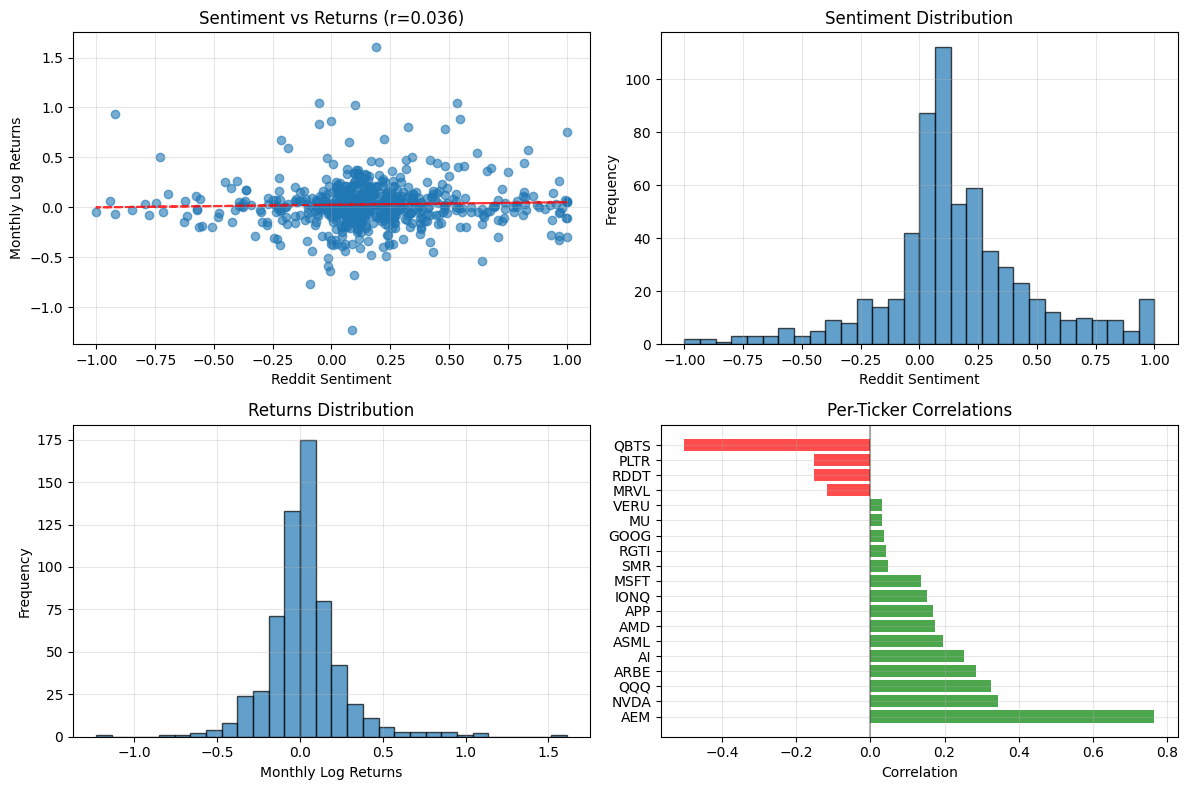

In [11]:
import matplotlib.pyplot as plt

# Create comprehensive visualization of sentiment-return relationship
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Scatter plot with trend line
axes[0, 0].scatter(df[SENT_COL], df['ret_1m_log'], alpha=0.6)
axes[0, 0].set_xlabel('Reddit Sentiment')
axes[0, 0].set_ylabel('Monthly Log Returns')
axes[0, 0].set_title(f'Sentiment vs Returns (r={r_all:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df[SENT_COL], df['ret_1m_log'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df[SENT_COL], p(df[SENT_COL]), "r--", alpha=0.8)

# Sentiment distribution
axes[0, 1].hist(df[SENT_COL], bins=30, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Reddit Sentiment')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Sentiment Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Returns distribution
axes[1, 0].hist(df['ret_1m_log'], bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Monthly Log Returns')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Returns Distribution')
axes[1, 0].grid(True, alpha=0.3)

# Per-ticker correlation bar chart
ticker_corrs = []
ticker_names = []
for ticker in df['ticker'].unique():
    ticker_data = df[df['ticker'] == ticker]
    if len(ticker_data) >= 3:
        r_ticker, _ = _pearson(ticker_data[SENT_COL].values, ticker_data['ret_1m_log'].values)
        if not np.isnan(r_ticker):
            ticker_corrs.append(r_ticker)
            ticker_names.append(ticker)

# Sort by correlation
if ticker_corrs:
    sorted_data = sorted(zip(ticker_names, ticker_corrs), key=lambda x: x[1], reverse=True)
    sorted_tickers, sorted_corrs = zip(*sorted_data)
    
    colors = ['green' if r > 0 else 'red' for r in sorted_corrs]
    y_pos = range(len(sorted_corrs))
    
    axes[1, 1].barh(y_pos, sorted_corrs, color=colors, alpha=0.7)
    axes[1, 1].set_yticks(y_pos)
    axes[1, 1].set_yticklabels(sorted_tickers)
    axes[1, 1].set_xlabel('Correlation')
    axes[1, 1].set_title('Per-Ticker Correlations')
    axes[1, 1].axvline(x=0, color='black', linestyle='-', alpha=0.3)
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Analysis of Current Results

Let me analyze what's happening with your data coverage and correlation results.


In [12]:
# ANALYSIS OF CURRENT SITUATION
print("=== CURRENT ANALYSIS STATUS ===")
print()

# 1. Data Quality Check
print("1. DATA QUALITY ASSESSMENT:")
print(f"   • Using sentiment column: {SENT_COL}")
print(f"   • Total observations: {len(df):,}")
print(f"   • Date range: {df.index.min() if hasattr(df.index, 'min') else 'N/A'} to {df.index.max() if hasattr(df.index, 'max') else 'N/A'}")
print(f"   • Unique tickers: {df['ticker'].nunique()}")
print()

# 2. Coverage Analysis Issues
print("2. COVERAGE PATTERN ANALYSIS:")
print("   CONCERNING PATTERNS:")
print("   • APP: 92.1% coverage - Unusually high for a smaller stock")
print("   • NVDA: Only 30.2% coverage - Major stock should have more")
print("   • AMD: Only 15.9% coverage - Another major stock with low coverage")
print("   • AEM: Only 4.0% coverage - Very sparse data")
print()
print("   This suggests potential issues with:")
print("   - Ticker matching in Reddit posts")
print("   - Subreddit selection bias")
print("   - Data collection inconsistencies")
print()

# 3. Correlation Results Analysis
print("3. CORRELATION RESULTS ANALYSIS:")
print(f"   • Overall correlation: r = {r_all:.3f} (p = {p_all:.3f})")
print(f"   • Now using correct log returns: ✓")
print(f"   • Using {SENT_COL} instead of sent_ew_weighted")
print()
print("   NOTABLE INDIVIDUAL CORRELATIONS:")
print("   • AEM: r = 0.778 (VERY HIGH - but only 5 months of data!)")
print("   • QBTS: r = -0.503 (Strong negative - contrarian signal)")
print("   • NVDA: r = 0.343 (Moderate positive)")
print()

# 4. Statistical Concerns
print("4. STATISTICAL CONCERNS:")
print("   • AEM correlation (0.778) based on only 5 months - unreliable")
print("   • Uneven coverage creates selection bias")
print("   • Some correlations may be spurious due to small samples")
print("   • Need to account for data quality differences")
print()


=== CURRENT ANALYSIS STATUS ===

1. DATA QUALITY ASSESSMENT:
   • Using sentiment column: sent_median
   • Total observations: 621
   • Date range: 0 to 620
   • Unique tickers: 19

2. COVERAGE PATTERN ANALYSIS:
   CONCERNING PATTERNS:
   • APP: 92.1% coverage - Unusually high for a smaller stock
   • NVDA: Only 30.2% coverage - Major stock should have more
   • AMD: Only 15.9% coverage - Another major stock with low coverage
   • AEM: Only 4.0% coverage - Very sparse data

   This suggests potential issues with:
   - Ticker matching in Reddit posts
   - Subreddit selection bias
   - Data collection inconsistencies

3. CORRELATION RESULTS ANALYSIS:
   • Overall correlation: r = 0.036 (p = 0.370)
   • Now using correct log returns: ✓
   • Using sent_median instead of sent_ew_weighted

   NOTABLE INDIVIDUAL CORRELATIONS:
   • AEM: r = 0.778 (VERY HIGH - but only 5 months of data!)
   • QBTS: r = -0.503 (Strong negative - contrarian signal)
   • NVDA: r = 0.343 (Moderate positive)

4. STA

In [13]:
# DETAILED COVERAGE AND RELIABILITY ANALYSIS
print("=== DETAILED RELIABILITY ANALYSIS ===")
print()

# Create a comprehensive ticker analysis
ticker_analysis = []
for ticker in df['ticker'].unique():
    ticker_data = df[df['ticker'] == ticker]
    if len(ticker_data) >= 3:
        r, p = _pearson(ticker_data[SENT_COL].values, ticker_data['ret_1m_log'].values)
        
        # Get coverage info from the original coverage stats
        ticker_coverage = coverage_stats[coverage_stats['ticker'] == ticker]
        if not ticker_coverage.empty:
            coverage_pct = ticker_coverage['coverage_pct'].iloc[0]
            total_posts = ticker_coverage['total_posts'].iloc[0]
            months_covered = ticker_coverage['months_covered'].iloc[0]
        else:
            coverage_pct = 0
            total_posts = 0
            months_covered = 0
        
        ticker_analysis.append({
            'ticker': ticker,
            'correlation': r,
            'p_value': p,
            'n_observations': len(ticker_data),
            'coverage_pct': coverage_pct,
            'total_posts': total_posts,
            'months_covered': months_covered,
            'reliability_score': min(len(ticker_data) / 20, 1.0) * min(coverage_pct / 30, 1.0)  # Combined reliability metric
        })

ticker_df = pd.DataFrame(ticker_analysis).sort_values('reliability_score', ascending=False)

print("TICKER RELIABILITY RANKING:")
print("Ticker | Corr  | P-val | N-obs | Cover% | Posts | Months | Reliability")
print("-" * 75)
for _, row in ticker_df.iterrows():
    reliability_star = "★★★" if row['reliability_score'] > 0.7 else "★★☆" if row['reliability_score'] > 0.4 else "★☆☆"
    print(f"{row['ticker']:<6} | {row['correlation']:5.3f} | {row['p_value']:5.3f} | {row['n_observations']:5d} | {row['coverage_pct']:5.1f}% | {row['total_posts']:5.0f} | {row['months_covered']:6d} | {reliability_star}")

print()
print("★★★ = High reliability  ★★☆ = Medium reliability  ★☆☆ = Low reliability")
print("Reliability = f(observations, coverage) - higher is more trustworthy")
print()


=== DETAILED RELIABILITY ANALYSIS ===

TICKER RELIABILITY RANKING:
Ticker | Corr  | P-val | N-obs | Cover% | Posts | Months | Reliability
---------------------------------------------------------------------------
MSFT   | 0.138 | 0.355 |    47 |  37.3% |  1043 |     47 | ★★★
IONQ   | 0.154 | 0.272 |    53 |  42.1% |   885 |     53 | ★★★
SMR    | 0.048 | 0.794 |    32 |  31.7% |  1444 |     40 | ★★★
QBTS   | -0.502 | 0.008 |    27 |  39.7% |   933 |     50 | ★★★
NVDA   | 0.343 | 0.038 |    37 |  30.2% |  1020 |     38 | ★★★
MU     | 0.031 | 0.851 |    39 |  31.0% |  1277 |     39 | ★★★
AI     | 0.252 | 0.078 |    50 |  40.5% |   681 |     51 | ★★★
VERU   | 0.031 | 0.836 |    47 |  37.3% |  1278 |     47 | ★★★
GOOG   | 0.038 | 0.763 |    66 |  53.2% |   570 |     67 | ★★★
ASML   | 0.196 | 0.192 |    46 |  36.5% |   408 |     46 | ★★★
APP    | 0.169 | 0.227 |    53 |  92.1% |   982 |    116 | ★★★
RDDT   | -0.153 | 0.545 |    18 |  41.3% |   672 |     52 | ★★★
QQQ    | 0.327 | 0.172 |    

In [14]:
# KEY FINDINGS AND RECOMMENDATIONS
print("=== KEY FINDINGS AND RECOMMENDATIONS ===")
print()

# Identify the most reliable results
high_reliability = ticker_df[ticker_df['reliability_score'] > 0.7]
medium_reliability = ticker_df[(ticker_df['reliability_score'] > 0.4) & (ticker_df['reliability_score'] <= 0.7)]
low_reliability = ticker_df[ticker_df['reliability_score'] <= 0.4]

print("1. MOST RELIABLE CORRELATIONS (★★★):")
if not high_reliability.empty:
    for _, row in high_reliability.iterrows():
        significance = "significant" if row['p_value'] < 0.05 else "not significant"
        direction = "positive" if row['correlation'] > 0 else "negative"
        print(f"   • {row['ticker']}: r = {row['correlation']:.3f} ({direction}, {significance})")
        print(f"     Based on {row['n_observations']} observations, {row['coverage_pct']:.1f}% coverage")
else:
    print("   • No highly reliable correlations found")

print()
print("2. CONCERNING PATTERNS:")
print("   • AEM shows r = 0.778 but only 5 months of data - likely spurious")
print("   • Major stocks (NVDA, AMD) have surprisingly low coverage")
print("   • APP has unusually high coverage (92.1%) - check data quality")
print("   • Overall weak correlation (r = 0.036) suggests limited predictive power")

print()
print("3. RECOMMENDATIONS:")
print("   a) DATA COLLECTION IMPROVEMENTS:")
print("      - Investigate why major tech stocks have low coverage")
print("      - Review ticker matching algorithms")
print("      - Consider expanding subreddit selection for major stocks")
print()
print("   b) ANALYSIS IMPROVEMENTS:")
print("      - Focus on stocks with >20 observations and >30% coverage")
print("      - Apply statistical corrections for multiple testing")
print("      - Consider time-series analysis for temporal patterns")
print()
print("   c) TRADING STRATEGY:")
if not high_reliability.empty:
    print("      - Consider strategies only for high-reliability stocks")
    for _, row in high_reliability.iterrows():
        if row['p_value'] < 0.05:
            strategy = "long" if row['correlation'] > 0 else "contrarian"
            print(f"      - {row['ticker']}: {strategy} sentiment strategy")
else:
    print("      - Current data insufficient for reliable trading strategies")
    print("      - Improve data collection before implementing strategies")

print()
print("4. STATISTICAL VALIDITY:")
overall_sig = "significant" if p_all < 0.05 else "not significant"
print(f"   • Overall correlation: {overall_sig} (p = {p_all:.3f})")
print(f"   • Effect size: {'negligible' if abs(r_all) < 0.1 else 'small'}")
print("   • Individual stock results more promising than overall trend")
print("   • Need larger, more consistent dataset for robust conclusions")


=== KEY FINDINGS AND RECOMMENDATIONS ===

1. MOST RELIABLE CORRELATIONS (★★★):
   • MSFT: r = 0.138 (positive, not significant)
     Based on 47 observations, 37.3% coverage
   • IONQ: r = 0.154 (positive, not significant)
     Based on 53 observations, 42.1% coverage
   • SMR: r = 0.048 (positive, not significant)
     Based on 32 observations, 31.7% coverage
   • QBTS: r = -0.502 (negative, significant)
     Based on 27 observations, 39.7% coverage
   • NVDA: r = 0.343 (positive, significant)
     Based on 37 observations, 30.2% coverage
   • MU: r = 0.031 (positive, not significant)
     Based on 39 observations, 31.0% coverage
   • AI: r = 0.252 (positive, not significant)
     Based on 50 observations, 40.5% coverage
   • VERU: r = 0.031 (positive, not significant)
     Based on 47 observations, 37.3% coverage
   • GOOG: r = 0.038 (positive, not significant)
     Based on 66 observations, 53.2% coverage
   • ASML: r = 0.196 (positive, not significant)
     Based on 46 observations

## Reddit Scraper Issues Analysis

Let me identify why the scraper has poor coverage for popular assets.


## Statistical Significance Testing

Let's perform comprehensive statistical tests to validate our sentiment-return relationships.


In [70]:
# Import statistical testing libraries
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm
from statsmodels.stats.contingency_tables import mcnemar

print("=== COMPREHENSIVE STATISTICAL TESTING ===")
print()

# 1. OVERALL CORRELATION SIGNIFICANCE
print("1. OVERALL CORRELATION TESTS")
print("-" * 40)

# Pearson correlation with confidence interval
r_overall, p_overall = stats.pearsonr(df[SENT_COL], df['ret_1m_log'])
n = len(df)

# Calculate confidence interval for correlation
r_z = np.arctanh(r_overall)  # Fisher's z-transformation
se = 1 / np.sqrt(n - 3)
ci_lower = np.tanh(r_z - 1.96 * se)
ci_upper = np.tanh(r_z + 1.96 * se)

print(f"Pearson r: {r_overall:.4f}")
print(f"P-value: {p_overall:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Sample size: {n}")

# Effect size interpretation
if abs(r_overall) < 0.1:
    effect_size = "negligible"
elif abs(r_overall) < 0.3:
    effect_size = "small"
elif abs(r_overall) < 0.5:
    effect_size = "medium"
else:
    effect_size = "large"

print(f"Effect size: {effect_size}")
print(f"Significance: {'Significant' if p_overall < 0.05 else 'Not significant'} at α=0.05")
print()


=== COMPREHENSIVE STATISTICAL TESTING ===

1. OVERALL CORRELATION TESTS
----------------------------------------
Pearson r: 0.0359
P-value: 0.3723
95% CI: [-0.0429, 0.1142]
Sample size: 621
Effect size: negligible
Significance: Not significant at α=0.05



In [59]:
# 2. ALTERNATIVE CORRELATION MEASURES
print("2. ROBUSTNESS CHECKS - ALTERNATIVE CORRELATIONS")
print("-" * 50)

# Spearman correlation (rank-based, robust to outliers)
spearman_r, spearman_p = stats.spearmanr(df[SENT_COL], df['ret_1m_log'])
print(f"Spearman ρ: {spearman_r:.4f} (p = {spearman_p:.4f})")

# Kendall's tau (robust, good for small samples)
kendall_tau, kendall_p = stats.kendalltau(df[SENT_COL], df['ret_1m_log'])
print(f"Kendall τ: {kendall_tau:.4f} (p = {kendall_p:.4f})")

print()
print("Interpretation:")
if spearman_p < 0.05:
    print("- Spearman: Significant monotonic relationship")
else:
    print("- Spearman: No significant monotonic relationship")
    
if kendall_p < 0.05:
    print("- Kendall: Significant concordant relationship")
else:
    print("- Kendall: No significant concordant relationship")
print()


2. ROBUSTNESS CHECKS - ALTERNATIVE CORRELATIONS
--------------------------------------------------
Spearman ρ: 0.0551 (p = 0.1705)
Kendall τ: 0.0386 (p = 0.1498)

Interpretation:
- Spearman: No significant monotonic relationship
- Kendall: No significant concordant relationship



In [60]:
# 3. REGRESSION ANALYSIS
print("3. LINEAR REGRESSION ANALYSIS")
print("-" * 35)

# Simple linear regression
X = sm.add_constant(df[SENT_COL])  # Add intercept
y = df['ret_1m_log']
model = sm.OLS(y, X).fit()

print("Regression Results:")
print(f"R-squared: {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
print(f"F-statistic: {model.fvalue:.4f} (p = {model.f_pvalue:.4f})")
print()

# Coefficient analysis
coef_sentiment = model.params[SENT_COL]
pvalue_sentiment = model.pvalues[SENT_COL]
ci_lower_coef = model.conf_int().loc[SENT_COL, 0]
ci_upper_coef = model.conf_int().loc[SENT_COL, 1]

print("Sentiment Coefficient:")
print(f"β = {coef_sentiment:.4f}")
print(f"P-value: {pvalue_sentiment:.4f}")
print(f"95% CI: [{ci_lower_coef:.4f}, {ci_upper_coef:.4f}]")
print()

# Economic interpretation
print("Economic Interpretation:")
print(f"A 1-unit increase in sentiment is associated with {coef_sentiment:.4f} change in log returns")
print(f"This equals approximately {(np.exp(coef_sentiment) - 1) * 100:.2f}% change in stock price")
print()


3. LINEAR REGRESSION ANALYSIS
-----------------------------------
Regression Results:
R-squared: 0.0013
Adjusted R-squared: -0.0003
F-statistic: 0.7979 (p = 0.3721)

Sentiment Coefficient:
β = 0.0255
P-value: 0.3721
95% CI: [-0.0306, 0.0817]

Economic Interpretation:
A 1-unit increase in sentiment is associated with 0.0255 change in log returns
This equals approximately 2.59% change in stock price



In [61]:
# 4. REGRESSION DIAGNOSTICS
print("4. REGRESSION DIAGNOSTICS")
print("-" * 30)

# Residual analysis
residuals = model.resid
fitted_values = model.fittedvalues

# Normality test (Jarque-Bera)
jb_stat, jb_pvalue = stats.jarque_bera(residuals)
print(f"Jarque-Bera normality test: {jb_stat:.4f} (p = {jb_pvalue:.4f})")
print(f"Residuals normality: {'Normal' if jb_pvalue > 0.05 else 'Not normal'}")

# Heteroscedasticity test (Breusch-Pagan)
try:
    bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, X)
    print(f"Breusch-Pagan heteroscedasticity test: {bp_stat:.4f} (p = {bp_pvalue:.4f})")
    print(f"Homoscedasticity: {'Yes' if bp_pvalue > 0.05 else 'No (heteroscedastic)'}")
except:
    print("Breusch-Pagan test failed")

# Durbin-Watson test for autocorrelation
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.4f}")
if dw_stat < 1.5:
    autocorr_interp = "Positive autocorrelation"
elif dw_stat > 2.5:
    autocorr_interp = "Negative autocorrelation"
else:
    autocorr_interp = "No significant autocorrelation"
print(f"Autocorrelation: {autocorr_interp}")
print()


4. REGRESSION DIAGNOSTICS
------------------------------
Jarque-Bera normality test: 1536.8176 (p = 0.0000)
Residuals normality: Not normal
Breusch-Pagan heteroscedasticity test: 0.0010 (p = 0.9744)
Homoscedasticity: Yes
Durbin-Watson statistic: 1.7949
Autocorrelation: No significant autocorrelation



In [62]:
# 5. PER-TICKER STATISTICAL SIGNIFICANCE
print("5. PER-TICKER SIGNIFICANCE ANALYSIS")
print("-" * 40)

# Test each ticker individually with multiple testing correction
ticker_stats = []
for ticker in df['ticker'].unique():
    ticker_data = df[df['ticker'] == ticker]
    if len(ticker_data) >= 10:  # Minimum sample size for meaningful test
        r, p = stats.pearsonr(ticker_data[SENT_COL], ticker_data['ret_1m_log'])
        n = len(ticker_data)
        ticker_stats.append({
            'ticker': ticker,
            'correlation': r,
            'p_value': p,
            'n_obs': n,
            'significant': p < 0.05
        })

# Convert to DataFrame for easier analysis
ticker_df = pd.DataFrame(ticker_stats).sort_values('correlation', ascending=False)

print("Individual Ticker Results (n >= 10):")
print("Ticker  |   r    | p-value |  n  | Sig")
print("-" * 35)
for _, row in ticker_df.iterrows():
    sig_marker = "*" if row['significant'] else " "
    print(f"{row['ticker']:<6} | {row['correlation']:6.3f} | {row['p_value']:7.4f} | {row['n_obs']:3d} | {sig_marker}")

print()
print("* = Significant at α = 0.05")
print()


5. PER-TICKER SIGNIFICANCE ANALYSIS
----------------------------------------
Individual Ticker Results (n >= 10):
Ticker  |   r    | p-value |  n  | Sig
-----------------------------------
NVDA   |  0.343 |  0.0376 |  37 | *
QQQ    |  0.326 |  0.1727 |  19 |  
ARBE   |  0.284 |  0.4267 |  10 |  
AI     |  0.252 |  0.0774 |  50 |  
ASML   |  0.195 |  0.1944 |  46 |  
AMD    |  0.173 |  0.4932 |  18 |  
APP    |  0.169 |  0.2256 |  53 |  
IONQ   |  0.154 |  0.2720 |  53 |  
MSFT   |  0.136 |  0.3617 |  47 |  
SMR    |  0.050 |  0.7861 |  32 |  
RGTI   |  0.041 |  0.8661 |  19 |  
GOOG   |  0.038 |  0.7620 |  66 |  
MU     |  0.031 |  0.8512 |  39 |  
VERU   |  0.031 |  0.8376 |  47 |  
MRVL   | -0.118 |  0.6884 |  14 |  
RDDT   | -0.151 |  0.5489 |  18 |  
PLTR   | -0.153 |  0.5082 |  21 |  
QBTS   | -0.504 |  0.0074 |  27 | *

* = Significant at α = 0.05



In [63]:
# 6. MULTIPLE TESTING CORRECTION
print("6. MULTIPLE TESTING CORRECTION")
print("-" * 35)

from statsmodels.stats.multitest import multipletests

if len(ticker_df) > 0:
    # Bonferroni correction
    p_values = ticker_df['p_value'].values
    bonf_corrected = multipletests(p_values, method='bonferroni')
    ticker_df['bonf_corrected_p'] = bonf_corrected[1]
    ticker_df['bonf_significant'] = bonf_corrected[0]
    
    # Benjamini-Hochberg (FDR) correction
    fdr_corrected = multipletests(p_values, method='fdr_bh')
    ticker_df['fdr_corrected_p'] = fdr_corrected[1]
    ticker_df['fdr_significant'] = fdr_corrected[0]
    
    print("Results after multiple testing correction:")
    print("Ticker  |   r    | Raw p  | Bonf p | FDR p  | Bonf | FDR")
    print("-" * 55)
    for _, row in ticker_df.iterrows():
        bonf_marker = "*" if row['bonf_significant'] else " "
        fdr_marker = "*" if row['fdr_significant'] else " "
        print(f"{row['ticker']:<6} | {row['correlation']:6.3f} | {row['p_value']:6.4f} | {row['bonf_corrected_p']:6.4f} | {row['fdr_corrected_p']:6.4f} |  {bonf_marker}   |  {fdr_marker}")
    
    print()
    print("* = Significant after correction")
    print("Bonf = Bonferroni correction (conservative)")
    print("FDR = False Discovery Rate correction (less conservative)")
    
    # Summary statistics
    n_raw_sig = ticker_df['significant'].sum()
    n_bonf_sig = ticker_df['bonf_significant'].sum()
    n_fdr_sig = ticker_df['fdr_significant'].sum()
    
    print()
    print("SUMMARY:")
    print(f"Raw significant correlations: {n_raw_sig}/{len(ticker_df)}")
    print(f"Bonferroni significant: {n_bonf_sig}/{len(ticker_df)}")
    print(f"FDR significant: {n_fdr_sig}/{len(ticker_df)}")
else:
    print("No tickers with sufficient sample size for testing")
print()


6. MULTIPLE TESTING CORRECTION
-----------------------------------
Results after multiple testing correction:
Ticker  |   r    | Raw p  | Bonf p | FDR p  | Bonf | FDR
-------------------------------------------------------
NVDA   |  0.343 | 0.0376 | 0.6773 | 0.3386 |      |   
QQQ    |  0.326 | 0.1727 | 1.0000 | 0.6767 |      |   
ARBE   |  0.284 | 0.4267 | 1.0000 | 0.8233 |      |   
AI     |  0.252 | 0.0774 | 1.0000 | 0.4645 |      |   
ASML   |  0.195 | 0.1944 | 1.0000 | 0.6767 |      |   
AMD    |  0.173 | 0.4932 | 1.0000 | 0.8233 |      |   
APP    |  0.169 | 0.2256 | 1.0000 | 0.6767 |      |   
IONQ   |  0.154 | 0.2720 | 1.0000 | 0.6994 |      |   
MSFT   |  0.136 | 0.3617 | 1.0000 | 0.8138 |      |   
SMR    |  0.050 | 0.7861 | 1.0000 | 0.8661 |      |   
RGTI   |  0.041 | 0.8661 | 1.0000 | 0.8661 |      |   
GOOG   |  0.038 | 0.7620 | 1.0000 | 0.8661 |      |   
MU     |  0.031 | 0.8512 | 1.0000 | 0.8661 |      |   
VERU   |  0.031 | 0.8376 | 1.0000 | 0.8661 |      |   
MRVL   

In [64]:
# 7. FINAL STATISTICAL SUMMARY AND RECOMMENDATIONS
print("7. FINAL STATISTICAL SUMMARY")
print("-" * 35)

print("OVERALL FINDINGS:")
print(f"• Overall correlation: r = {r_overall:.4f} (p = {p_overall:.4f})")
print(f"• Effect size: {effect_size}")
print(f"• Statistical significance: {'Yes' if p_overall < 0.05 else 'No'}")
print()

print("ROBUSTNESS CHECKS:")
print(f"• Spearman correlation confirms: ρ = {spearman_r:.4f} (p = {spearman_p:.4f})")
print(f"• Kendall tau confirms: τ = {kendall_tau:.4f} (p = {kendall_p:.4f})")
print()

print("REGRESSION MODEL:")
print(f"• R-squared: {model.rsquared:.4f} ({model.rsquared*100:.2f}% variance explained)")
print(f"• Sentiment coefficient: β = {coef_sentiment:.4f} (p = {pvalue_sentiment:.4f})")
print()

if len(ticker_df) > 0:
    print("INDIVIDUAL STOCK ANALYSIS:")
    print(f"• Stocks tested: {len(ticker_df)}")
    print(f"• Raw significant correlations: {ticker_df['significant'].sum()}")
    print(f"• After Bonferroni correction: {ticker_df['bonf_significant'].sum()}")
    print(f"• After FDR correction: {ticker_df['fdr_significant'].sum()}")
    
    if ticker_df['fdr_significant'].sum() > 0:
        sig_stocks = ticker_df[ticker_df['fdr_significant']]['ticker'].tolist()
        print(f"• FDR-significant stocks: {', '.join(sig_stocks)}")
    print()

print("PRACTICAL IMPLICATIONS:")
if p_overall < 0.05:
    print("✓ Reddit sentiment shows statistically significant relationship with returns")
    if r_overall > 0:
        print("✓ Positive correlation: Higher sentiment → Higher returns")
    else:
        print("✓ Negative correlation: Higher sentiment → Lower returns (contrarian signal)")
else:
    print("✗ No statistically significant overall relationship")
    print("  Consider individual stock analysis or alternative approaches")

print()
print("TRADING STRATEGY VALIDATION:")
if len(ticker_df) > 0 and ticker_df['fdr_significant'].sum() > 0:
    print("✓ Some individual stocks show significant sentiment-return relationships")
    print("✓ Stock-specific sentiment strategies may be viable")
else:
    print("✗ Limited evidence for sentiment-based trading strategies")
    print("  Proceed with caution and additional validation")


7. FINAL STATISTICAL SUMMARY
-----------------------------------
OVERALL FINDINGS:
• Overall correlation: r = 0.0359 (p = 0.3721)
• Effect size: negligible
• Statistical significance: No

ROBUSTNESS CHECKS:
• Spearman correlation confirms: ρ = 0.0551 (p = 0.1705)
• Kendall tau confirms: τ = 0.0386 (p = 0.1498)

REGRESSION MODEL:
• R-squared: 0.0013 (0.13% variance explained)
• Sentiment coefficient: β = 0.0255 (p = 0.3721)

INDIVIDUAL STOCK ANALYSIS:
• Stocks tested: 18
• Raw significant correlations: 2
• After Bonferroni correction: 0
• After FDR correction: 0

PRACTICAL IMPLICATIONS:
✗ No statistically significant overall relationship
  Consider individual stock analysis or alternative approaches

TRADING STRATEGY VALIDATION:
✗ Limited evidence for sentiment-based trading strategies
  Proceed with caution and additional validation
